# 04 LPU Ensemble -- CI Band Visualization

Local Parameter Uncertainty via SciPy `leastsq` Jacobian.
Fits Q_sim = a*WAM + b, extracts parameter covariance from inv(JtJ),
and propagates uncertainty via MVN sampling of [a, b] parameter pairs.

Satisfies ROADMAP Phase 5 success criteria:
1. LPU ensemble CI band plot (5th-95th percentile)
2. Diagnostics: fitted a, b, sigma2, kappa(JtJ), SVD fallback flag
3. Ensemble and summary stats CSVs exported via existing writers

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from red_tide_reanalysis.ingestion.obs_loader import load_observations
from red_tide_reanalysis.ingestion.wam_loader import load_wam_model
from red_tide_reanalysis.ingestion.align import align_obs_model
from red_tide_reanalysis.lpu.method import LPUMethod
from red_tide_reanalysis.writers.ensemble_writer import write_ensemble_csv
from red_tide_reanalysis.writers.stats_writer import write_stats_csv

## 1. Load and Align Data

In [2]:
obs_raw = load_observations("input/Arcadia_Unified_TN_Reanalysis_2000_2023.csv")
wam_raw = load_wam_model("input/Station_02296750 (ARCADIA)_reach000084_83.csv")
obs, model = align_obs_model(obs_raw, wam_raw)
print(f"Aligned series: {len(obs)} timesteps, {obs.index[0].date()} to {obs.index[-1].date()}")

Aligned series: 787 timesteps, 2000-01-05 to 2023-12-07


## 2. Configure and Run LPU

In [3]:
method = LPUMethod(n_members=200, station_id="02296750_peace_river")
result = method.run(obs, model, n_members=200, seed=42)

print(f"LPU diagnostics:")
print(f"  fitted a     : {result.config['fitted_a']:.6f}")
print(f"  fitted b     : {result.config['fitted_b']:.6f}  mg/L")
print(f"  sigma2       : {result.config['sigma2']:.6f}")
print(f"  kappa(JtJ)   : {result.config['kappa']:.3e}")
print(f"  SVD fallback : {result.config['svd_fallback']}")
print(f"Ensemble shape : {result.members.shape}")

LPU diagnostics:
  fitted a     : -0.042043
  fitted b     : 1.591586  mg/L
  sigma2       : 0.018870
  kappa(JtJ)   : 2.305e+02
  SVD fallback : False
Ensemble shape : (200, 787)


## 3. CI Band Visualization

5th-95th percentile shaded band from the 200-member LPU ensemble.

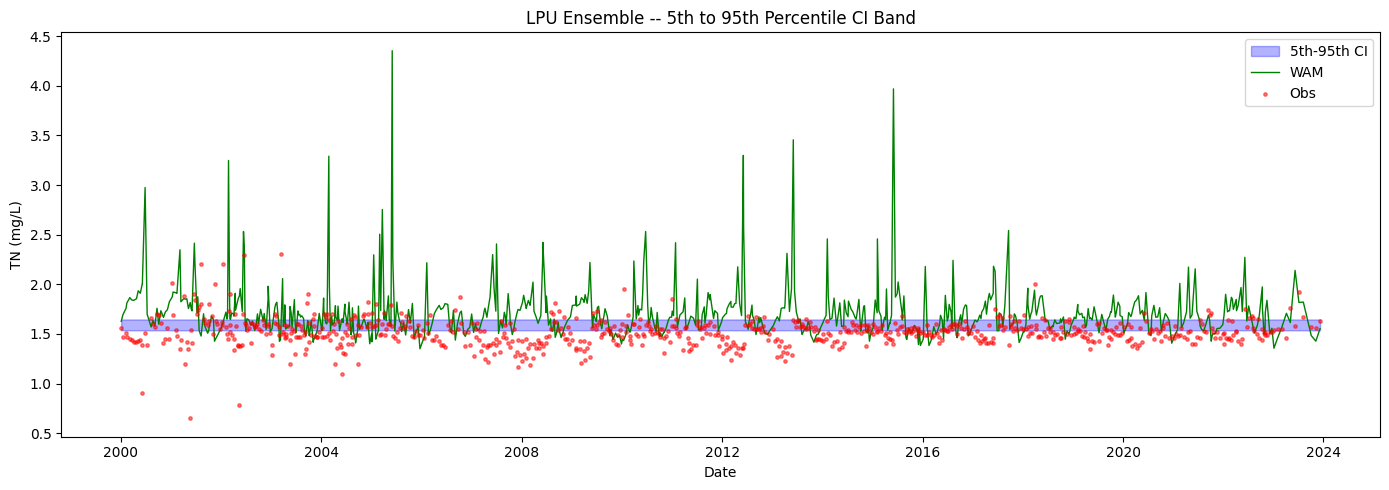

In [4]:
p5  = np.percentile(result.members, 5,  axis=0)
p95 = np.percentile(result.members, 95, axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(result.time_index, p5, p95, alpha=0.3, color="blue", label="5th-95th CI")
ax.plot(result.time_index, result.model_output.values, color="green", linewidth=1.0, label="WAM")
ax.scatter(result.time_index, result.observations.values, s=6, color="red", alpha=0.5, label="Obs", zorder=5)
ax.set_xlabel("Date")
ax.set_ylabel("TN (mg/L)")
ax.set_title("LPU Ensemble -- 5th to 95th Percentile CI Band")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Export CSVs

In [5]:
output_dir = Path("output")
ens_path = write_ensemble_csv(result, output_dir / "ensembles")
stats_path = write_stats_csv(result, output_dir / "stats")
print(f"Ensemble CSV: {ens_path}")
print(f"Stats CSV:    {stats_path}")

Ensemble CSV: output\ensembles\lpu_02296750_peace_river_total_nitrogen_members.csv
Stats CSV:    output\stats\lpu_02296750_peace_river_total_nitrogen_stats.csv


## Summary

- Forward model: Q_sim = a * WAM + b (same as GLUE, different uncertainty quantification)
- Fitting: scipy.optimize.leastsq with full_output=True
- Parameter covariance: pcov = sigma2 * inv(JtJ)
- Condition number check: kappa(JtJ) > 1e8 triggers SVD pseudo-inverse fallback
- Ensemble: 200 members via MVN sampling of [a, b] parameter pairs
- Output files: `output/ensembles/` and `output/stats/`